In [12]:
import pandas as pd
import numpy as np


from sklearn.metrics import matthews_corrcoef

from sklearn.model_selection import train_test_split
import getting_threshold_genes as gtg
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from ydata_profiling import ProfileReport
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score


from sklearn.metrics import make_scorer, matthews_corrcoef
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

from sklearn.metrics import make_scorer, matthews_corrcoef
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

In [13]:
eigth_bins_original = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_train.csv")
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_test.csv")
eigth_bins_original=eigth_bins_original[eigth_bins_original["Experiment"]=="GSE167186"]
eigth_bins_test=eigth_bins_test[eigth_bins_test["Experiment"]=="GSE167186"]
seq_metadata_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/All_rna_samples_metadata_edit.csv"
seq_metadata = pd.read_csv(seq_metadata_path)
rnaSeq_origial= pd.merge(eigth_bins_original, seq_metadata, on='Sample', how='inner')
rnaSeq_test= pd.merge(eigth_bins_test, seq_metadata, on='Sample', how='inner')
x_labels= rnaSeq_origial["Status"].value_counts()


In [14]:
rnaSeq_origial["Age_C"] = np.where(rnaSeq_origial["Age"] > 65, "Old", "Young")
rnaSeq_origial["Class"]=rnaSeq_origial["Status"].astype(str) +" "+ rnaSeq_origial["Age_C"].astype(str)

rnaSeq_test["Age_C"] = np.where(rnaSeq_test["Age"] > 65, "Old", "Young")
rnaSeq_test["Class"]=rnaSeq_test["Status"].astype(str) +" "+ rnaSeq_test["Age_C"].astype(str)
scorer = make_scorer(matthews_corrcoef)


In [15]:
print("Training:",len(eigth_bins_original), "Testing:",len(eigth_bins_test))

Training: 43 Testing: 32


In [16]:
ridge_selection = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_feature_selection.csv"
df = gtg.get_df(ridge_selection)# alpha=0.05
rnaseq_genes = df["Ensembl"]
len(rnaseq_genes)
rnaseq_genes = rnaseq_genes.to_list()

rnaseq_genes.append("Status")

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
0.1450134054998397


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/numpy/lib/polynomial.py:668: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


In [17]:
top_35_genes_age = ["ENSG00000101892.11",
"ENSG00000277654.5",
"ENSG00000127241.16",
"ENSG00000171055.14",
"ENSG00000170873.18",
"ENSG00000137700.17",
"ENSG00000177548.12",
"ENSG00000123095.5",
"ENSG00000111640.14",
"ENSG00000127184.12",
"ENSG00000089101.17",
"ENSG00000101745.16",
"ENSG00000082397.17",
"ENSG00000178053.17",
"ENSG00000227097.5",
"ENSG00000185760.15",
"ENSG00000145675.14",
"ENSG00000124370.10",
"ENSG00000130935.9",
"ENSG00000185551.14",
"ENSG00000270388.1",
"ENSG00000131378.13",
"ENSG00000222427.1",
"ENSG00000150722.10",
"ENSG00000112562.18",
"ENSG00000169083.16",
"ENSG00000133315.10",
"ENSG00000177508.11",
"ENSG00000182108.10",
"ENSG00000199455.1",
"ENSG00000085231.13",
"ENSG00000238391.1",
"ENSG00000112031.15",
"ENSG00000188176.11",
"ENSG00000069275.12",
"Status"
]
top_35_genes_age.extend(["Sample", "Age","Sex", "Age_C", "Class", "Experiment"])
rnaseq_genes.extend(["Sample", "Age","Sex", "Age_C", "Class", "Experiment"])


In [18]:
remove_youn = rnaSeq_origial[rnaSeq_origial["Age_C"]!="Young"]
#remove_youn = rnaSeq_origial[rnaSeq_origial["Class"]!="Healthy Old"]
#rnaseq_genes.extend(["Sample", "Age","Sex", "Age_C", "Class", "Experiment"])
remove_youn = remove_youn[rnaseq_genes]

remove_youn=remove_youn[top_35_genes_age]

In [19]:
remove_youn["Class"].value_counts()

Class
Sarcopenia Old    15
Healthy Old       14
Name: count, dtype: int64

<Figure size 1000x600 with 0 Axes>

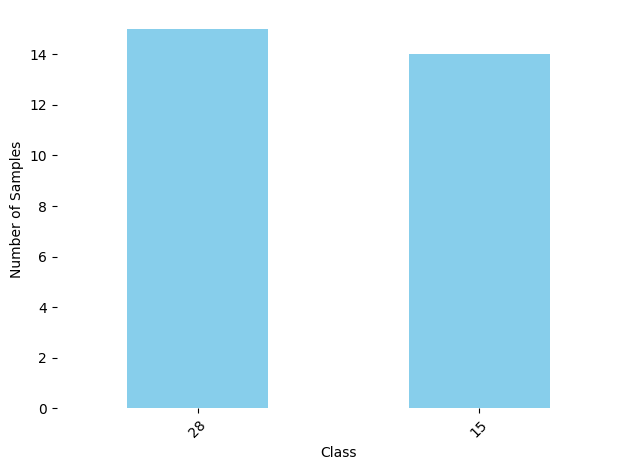

In [20]:
from matplotlib import pyplot as plt
standar_age_ranges = remove_youn["Class"].value_counts()
plt.figure(figsize=(10, 6))
pd.DataFrame(standar_age_ranges).plot(kind='bar', xticks=range(len(standar_age_ranges)), color='skyblue', legend=False)
#plt.title('Distribution of Age Groups Training Set')
#plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(range(len(standar_age_ranges)), x_labels, rotation=45)  # Setting x-tick labels
plt.tight_layout()
plt.box(False)

plt.show()

In [21]:
#import feature_selection as fs
#section_df = remove_youn.drop(columns=["Sample", "Status", "Age","Sex", "Age_C", "Class", "Experiment"])
#section_df_age = remove_youn["Status"]
#features, status = fs.smote(X=section_df, y=section_df_age)
#remove_youn = pd.DataFrame(features, columns=section_df.columns)
#remove_youn["Status"] = status
remove_youn["Status"].value_counts()

Status
Sarcopenia    15
Healthy       14
Name: count, dtype: int64

In [22]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = train_test_split(remove_youn.drop(["Sample", "Status", "Age","Sex", "Age_C", "Class", "Experiment"], axis=1), remove_youn["Status"], remove_youn, test_size=0.01, random_state=42)
#seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = train_test_split(remove_youn.drop(["Status"], axis=1), remove_youn["Status"], remove_youn, test_size=0.4, random_state=42)


In [23]:
print("X_train shape: ", seq_X_train.shape, "X_test shape: ", seq_X_test.shape, "y_train shape: ", seq_y_train.shape, "y_test shape: ", seq_y_test.shape, "z_train shape: ", seq_z_train.shape, "z_test shape: ", seq_z_test.shape)
print("Train Healthy: ", seq_y_train.value_counts(), "Test Sarcopenia: ", seq_y_test.value_counts())

X_train shape:  (28, 35) X_test shape:  (1, 35) y_train shape:  (28,) y_test shape:  (1,) z_train shape:  (28, 42) z_test shape:  (1, 42)
Train Healthy:  Status
Healthy       14
Sarcopenia    14
Name: count, dtype: int64 Test Sarcopenia:  Status
Sarcopenia    1
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
scorer = make_scorer(matthews_corrcoef)
seq_y_train = seq_y_train.replace({"Healthy": 0, "Sarcopenia": 1})
seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100, 1000, 10000, 100000],  # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001],  # Kernel coefficient for 'rbf' and 'poly'
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],  # Kernel type
}

# Create SVM model
svm_model = SVC()

# Perform grid search with cross-validation
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring=scorer)
grid_search.fit(seq_X_train, seq_y_train)

# Get best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score (mcc):", best_score)

# Use best model for prediction
best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(seq_X_test)
y_pred

/tmp/ipykernel_92690/2028479386.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  seq_y_train = seq_y_train.replace({"Healthy": 0, "Sarcopenia": 1})
/tmp/ipykernel_92690/2028479386.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})


Best Parameters: {'C': 10000, 'gamma': 0.1, 'kernel': 'rbf'}
Best Score (mcc): 0.5280932520471029


array([0])

In [25]:
remove_youn = rnaSeq_origial[rnaSeq_origial["Age_C"]!="Young"]
#remove_youn = rnaSeq_origial[rnaSeq_origial["Class"]!="Healthy Old"]
#rnaseq_genes.extend(["Sample", "Age","Sex", "Age_C", "Class", "Experiment"])
remove_youn = remove_youn[rnaseq_genes]

#remove_youn=remove_youn[top_35_genes_age]

In [26]:
test_data = rnaSeq_test[rnaSeq_test["Age_C"]!="Young"]
#test_data = rnaSeq_test[rnaSeq_test["Class"]!="Healthy Old"]
#rnaseq_genes.extend(["Sample", "Age"])
test_data = test_data[rnaseq_genes]
test_data=test_data[top_35_genes_age]
test_data["Class"].value_counts()


Class
Healthy Old       14
Sarcopenia Old     8
Name: count, dtype: int64

In [27]:
test_data.columns[-15:]

Index(['ENSG00000177508.11', 'ENSG00000182108.10', 'ENSG00000199455.1',
       'ENSG00000085231.13', 'ENSG00000238391.1', 'ENSG00000112031.15',
       'ENSG00000188176.11', 'ENSG00000069275.12', 'Status', 'Sample', 'Age',
       'Sex', 'Age_C', 'Class', 'Experiment'],
      dtype='object')

In [28]:
seq_X_test = test_data.drop(columns=["Sample", "Status", 'Sample', 'Age','Sex', 'Age_C', 'Class', 'Experiment'])
seq_y_test = test_data["Status"]
seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})

/tmp/ipykernel_92690/153073242.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})


In [29]:
seq_X_test.shape

(22, 35)

In [30]:
best_svm_model = grid_search.best_estimator_


In [31]:
y_pred = best_svm_model.predict(seq_X_train)

conf_matrix_train = confusion_matrix(seq_y_train, y_pred)
print(conf_matrix_train)

[[13  1]
 [ 3 11]]


In [32]:

y_pred = best_svm_model.predict(seq_X_test)
print("Test Labels:", seq_y_test.values)
print("Predicted Labels:", y_pred)
mcc = matthews_corrcoef(seq_y_test, y_pred)
print("MCC:", mcc)
conf_matrix_test = confusion_matrix(seq_y_test, y_pred)
print(conf_matrix_test)

Test Labels: [1 0 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0]
Predicted Labels: [1 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 1 0 0]
MCC: 0.4485426135725303
[[10  4]
 [ 2  6]]


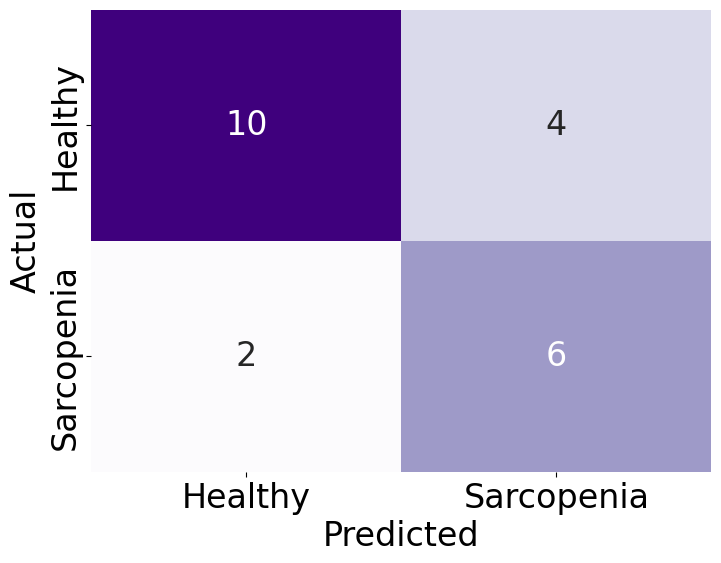

In [37]:
from matplotlib import pyplot as plt
import seaborn as sns

x_labels = ['Healthy', 'Sarcopenia']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, cmap='Purples', annot_kws={'size': 24},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True, cbar=False)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Predicted', fontsize=24)
plt.ylabel('Actual', fontsize=24)
#plt.title('Confusion Matrix')

plt.show()

In [393]:
sen = recall_score(seq_y_test, y_pred)
spc = recall_score(seq_y_test, y_pred, pos_label=0)
mcc = matthews_corrcoef(seq_y_test, y_pred)
ppv = precision_score(seq_y_test, y_pred)
npv = precision_score(seq_y_test, y_pred, pos_label=0)
f1 = f1_score(seq_y_test, y_pred)
print("Sensitivity:", sen)
print("Specificity:", spc)
print("PPV:", ppv)
print("NPV:", npv)
print("F1 Score:", f1)
print("MCC:", mcc)


Sensitivity: 0.75
Specificity: 0.7142857142857143
PPV: 0.6
NPV: 0.8333333333333334
F1 Score: 0.6666666666666666
MCC: 0.4485426135725303


In [394]:
auc = roc_auc_score(seq_y_test, y_pred)
print("AUC:", auc)

AUC: 0.7321428571428571


In [388]:
resolutuion_df = pd.DataFrame(seq_X_test)
resolutuion_df["Status"] = seq_y_test
resolutuion_df["Predicted"] = y_pred
resolutuion_df["Sample"] = seq_z_test["Sample"]

In [389]:
resolutuion_df#[resolutuion_df["Predicted"]!=resolutuion_df["Status"]]

,ENSG00000101892.11,ENSG00000277654.5,ENSG00000127241.16,ENSG00000171055.14,ENSG00000170873.18,ENSG00000137700.17,ENSG00000177548.12,ENSG00000123095.5,ENSG00000111640.14,ENSG00000127184.12,...,ENSG00000182108.10,ENSG00000199455.1,ENSG00000085231.13,ENSG00000238391.1,ENSG00000112031.15,ENSG00000188176.11,ENSG00000069275.12,Status,Predicted,Sample
2,-0.013576,-0.017573,-0.018809,0.079021,0.011138,-0.017531,-0.005781,0.023613,0.218978,0.349604,...,-0.023543,-0.023134,-0.022374,-0.016907,-0.012078,0.014042,0.599617,1,1,NaN
3,-0.013770,0.008965,-0.018814,0.067705,0.003135,-0.021662,-0.010222,0.057790,0.252093,0.467672,...,-0.018172,-0.023044,-0.016882,-0.016833,-0.016884,0.015066,0.426739,0,1,NaN
4,-0.013345,-0.008889,-0.017342,0.135894,0.006269,-0.016484,0.005209,0.090227,0.390373,0.697329,...,-0.017985,-0.024436,-0.020356,-0.017975,0.003730,0.016833,0.548477,1,0,NaN
5,-0.020136,0.000602,-0.023779,0.112233,0.005176,-0.020348,0.019328,0.037717,0.472858,1.046321,...,-0.019012,-0.026683,-0.019146,-0.019819,-0.014104,0.015207,0.791924,1,1,NaN
6,-0.014624,-0.019614,-0.017838,0.033123,0.002441,-0.019019,-0.014668,0.003381,0.285106,0.600204,...,-0.018555,-0.022372,-0.016918,-0.016282,-0.018454,0.013700,0.279574,1,0,NaN
8,-0.012251,-0.016621,-0.018863,0.180972,0.010839,-0.019966,-0.011039,0.013795,0.228092,0.526763,...,-0.019457,-0.023767,-0.017985,-0.017426,-0.005508,0.013591,0.599799,0,0,NaN
11,-0.013948,-0.011917,-0.016460,0.066163,0.007874,-0.015541,-0.015882,0.029216,0.219667,0.356402,...,-0.020975,-0.022586,-0.015177,-0.016457,-0.014982,0.014940,0.475738,0,0,NaN
12,-0.009344,0.010863,-0.020640,0.253797,0.011884,-0.017185,-0.005170,0.125359,0.294718,0.917321,...,-0.020115,-0.026202,-0.016385,-0.019425,-0.009249,0.013492,0.765267,1,1,NaN
13,-0.013168,-0.016065,-0.019614,0.069654,0.006891,-0.016100,0.000713,0.042076,0.300474,0.496704,...,-0.023952,-0.023553,-0.020161,-0.017250,-0.017409,0.013987,0.563613,0,0,NaN
14,-0.014659,-0.009130,-0.018552,0.159233,0.000499,-0.009968,0.012210,0.044157,0.331551,0.667848,...,-0.014703,-0.024162,-0.014604,-0.017751,0.000965,0.014555,0.584654,0,0,NaN


In [390]:
def spcy(seq_y_test, y_pred):
    spc = precision_score(seq_y_test, y_pred)
    return spc